In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("analise_robusta.csv")

## 1- Valor Medio BolsaFamilia Ajustada pela quanrtidade de abandono EF

In [ ]:

abandono_ef = df.melt(
    id_vars=["UF"],  
    value_vars=[col for col in df.columns if "Abandono_EM" in col], 
    var_name="Ano",  
    value_name="Abandono_EM"  
)
abandono_ef["Ano"] = abandono_ef["Ano"].str.extract(r'(\d{4})').astype(int)


valor_bf = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "valor_medio_bf_ajustado_" in col],
    var_name="Ano",
    value_name="Valor_medio_BF"
)
valor_bf["Ano"] = valor_bf["Ano"].str.extract(r'(\d{4})').astype(int)


df_final = pd.merge(abandono_ef, valor_bf, on=["UF", "Ano"])

print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF
0  AC  2007         5512          184.37
1  AL  2007        32874          175.03
2  AP  2007         8513          189.19
3  AM  2007        21077          189.42
4  BA  2007       161873          178.15


In [ ]:
IDHM_EDUCACAO = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "IDHM Educação" in col],
    var_name="Ano",
    value_name="IDHM Educação"
)
IDHM_EDUCACAO ["Ano"] = IDHM_EDUCACAO["Ano"].str.extract(r'(\d{4})').astype(int)



df_final = pd.merge(df_final, IDHM_EDUCACAO, on=["UF", "Ano"])

print(df_final.head())




   UF   Ano  Abandono_EM  Valor_medio_BF  IDHM Educação
0  AC  2012         4006          361.93          0.649
1  AL  2012        23988          294.55          0.587
2  AP  2012         6925          343.57          0.659
3  AM  2012        21056          338.33          0.632
4  BA  2012        83059          285.55          0.593


In [ ]:
IDHM_RENDA = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "IDHM Renda" in col],
    var_name="Ano",
    value_name="IDHM Renda"
)
IDHM_RENDA["Ano"] = IDHM_RENDA["Ano"].str.extract(r'(\d{4})').astype(int)


df_final = pd.merge(df_final, IDHM_RENDA, on=["UF", "Ano"])


print(df_final.head())



   UF   Ano  Abandono_EM  Valor_medio_BF  IDHM Educação  IDHM Renda
0  AC  2012         4006          361.93          0.649       0.670
1  AL  2012        23988          294.55          0.587       0.627
2  AP  2012         6925          343.57          0.659       0.673
3  AM  2012        21056          338.33          0.632       0.683
4  BA  2012        83059          285.55          0.593       0.666


In [ ]:
INDICE_ATKINSON= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "Índice de Atkinson - Renda" in col],
    var_name="Ano",
    value_name="Índice de Atkinson Renda"
)
INDICE_ATKINSON["Ano"] = INDICE_ATKINSON["Ano"].str.extract(r'(\d{4})').astype(int)

df_final = pd.merge(df_final, INDICE_ATKINSON, on=["UF", "Ano"])

print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF  IDHM Educação  IDHM Renda  \
0  AC  2012         4006          361.93          0.649       0.670   
1  AL  2012        23988          294.55          0.587       0.627   
2  AP  2012         6925          343.57          0.659       0.673   
3  AM  2012        21056          338.33          0.632       0.683   
4  BA  2012        83059          285.55          0.593       0.666   

   Índice de Atkinson Renda  
0                     0.422  
1                     0.352  
2                     0.361  
3                     0.417  
4                     0.405  


In [ ]:
INDICE_ATKINSON= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "Índice de Atkinson - Educação" in col],
    var_name="Ano",
    value_name="Índice de Atkinson Educacao"
)
INDICE_ATKINSON["Ano"] = INDICE_ATKINSON["Ano"].str.extract(r'(\d{4})').astype(int)

df_final = pd.merge(df_final, INDICE_ATKINSON, on=["UF", "Ano"])

print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF  IDHM Educação  IDHM Renda  \
0  AC  2012         4006          361.93          0.649       0.670   
1  AL  2012        23988          294.55          0.587       0.627   
2  AP  2012         6925          343.57          0.659       0.673   
3  AM  2012        21056          338.33          0.632       0.683   
4  BA  2012        83059          285.55          0.593       0.666   

   Índice de Atkinson Renda  Índice de Atkinson Educacao  
0                     0.422                        0.281  
1                     0.352                        0.296  
2                     0.361                        0.184  
3                     0.417                        0.202  
4                     0.405                        0.275  


In [ ]:

QTD_FAMILIAS= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "qtd_familias_beneficiarias_bolsa_familia_ajustado_" in col],
    var_name="Ano",
    value_name="QTD_FAMILIAS_BF"
)
QTD_FAMILIAS["Ano"] = QTD_FAMILIAS["Ano"].str.extract(r'(\d{4})').astype(int)

df_final = pd.merge(df_final,QTD_FAMILIAS, on=["UF", "Ano"])

print(df_final.head())


   UF   Ano  Abandono_EM  Valor_medio_BF  IDHM Educação  IDHM Renda  \
0  AC  2012         4006          361.93          0.649       0.670   
1  AL  2012        23988          294.55          0.587       0.627   
2  AP  2012         6925          343.57          0.659       0.673   
3  AM  2012        21056          338.33          0.632       0.683   
4  BA  2012        83059          285.55          0.593       0.666   

   Índice de Atkinson Renda  Índice de Atkinson Educacao  QTD_FAMILIAS_BF  
0                     0.422                        0.281          67021.0  
1                     0.352                        0.296         429494.0  
2                     0.361                        0.184          52285.0  
3                     0.417                        0.202         323646.0  
4                     0.405                        0.275        1777116.0  


In [10]:
df_rendaPerCapta= pd.read_csv("idhm_renda_per_capita.csv")

In [ ]:


PERCAPTA= df_rendaPerCapta.melt(
    id_vars=["UF"],
    value_vars=[col for col in df_rendaPerCapta.columns if "Renda per capita " in col],
    var_name="Ano",
    value_name="rendaPercapta"
)
PERCAPTA["Ano"] = PERCAPTA["Ano"].str.extract(r'(\d{4})').astype(int)

df_final = pd.merge(df_final,PERCAPTA, on=["UF", "Ano"])

df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta
0,AC,2012,4006,361.93,0.649,0.670,0.422,0.281,67021.0,516.75
1,AL,2012,23988,294.55,0.587,0.627,0.352,0.296,429494.0,395.06
2,AP,2012,6925,343.57,0.659,0.673,0.361,0.184,52285.0,528.23
3,AM,2012,21056,338.33,0.632,0.683,0.417,0.202,323646.0,559.44
4,BA,2012,83059,285.55,0.593,0.666,0.405,0.275,1777116.0,503.29


In [ ]:

IndiciDeGINI= gini.melt(
    id_vars=["UF"],
    value_vars=[col for col in gini.columns if "Índice de Gini " in col],
    var_name="Ano",
    value_name="IndiceDeGINI"
)
IndiciDeGINI["Ano"] = IndiciDeGINI["Ano"].str.extract(r'(\d{4})').astype(int)

df_final = pd.merge(df_final,IndiciDeGINI, on=["UF", "Ano"])

df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI
0,AC,2012,4006,361.93,0.649,0.670,0.422,0.281,67021.0,516.75,0.566
1,AL,2012,23988,294.55,0.587,0.627,0.352,0.296,429494.0,395.06,0.503
2,AP,2012,6925,343.57,0.659,0.673,0.361,0.184,52285.0,528.23,0.528
3,AM,2012,21056,338.33,0.632,0.683,0.417,0.202,323646.0,559.44,0.589
4,BA,2012,83059,285.55,0.593,0.666,0.405,0.275,1777116.0,503.29,0.563


In [14]:
df_final

,UF,Ano,Abandono_EM,Valor_medio_BF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI
0,AC,2012,4006,361.93,0.649,0.670,0.422,0.281,67021.0,516.75,0.566
1,AL,2012,23988,294.55,0.587,0.627,0.352,0.296,429494.0,395.06,0.503
2,AP,2012,6925,343.57,0.659,0.673,0.361,0.184,52285.0,528.23,0.528
3,AM,2012,21056,338.33,0.632,0.683,0.417,0.202,323646.0,559.44,0.589
4,BA,2012,83059,285.55,0.593,0.666,0.405,0.275,1777116.0,503.29,0.563
...,...,...,...,...,...,...,...,...,...,...,...
265,RR,2021,1282,152.57,0.673,0.680,0.447,0.156,43082.0,549.54,0.596
266,SC,2021,19724,125.56,0.790,0.759,0.256,0.116,115584.0,901.20,0.424
267,SP,2021,54267,111.70,0.839,0.771,0.352,0.104,1394844.0,971.82,0.533
268,SE,2021,2579,96.25,0.684,0.662,0.426,0.195,239099.0,492.78,0.568


In [15]:
taxas = pd.read_csv("TaxasDeDesocupacaoOcupacaoParticipacao.csv")

In [16]:
taxas

,UF,Ano,Trimestre,Taxa_Desocupacao,Nivel_Ocupacao,Taxa_Participacao
0,RO,2012,2,8.1,58.1,63.2
1,AC,2012,2,9.3,53.2,58.6
2,AM,2012,2,11.1,56.3,63.3
3,RR,2012,2,8.6,57.1,62.5
4,PA,2012,2,8.0,55.6,60.5
...,...,...,...,...,...,...
10795,RS,2021,2,8.1,59.5,64.8
10796,MS,2021,2,6.4,62.3,66.5
10797,MT,2021,2,5.9,62.5,66.5
10798,GO,2021,2,8.8,59.7,65.5


In [ ]:
TAXADESOCUPACAO = taxas[["UF","Ano","Taxa_Desocupacao"]]

df_final = pd.merge(df_final,TAXADESOCUPACAO, on=["UF", "Ano"])

df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI,Taxa_Desocupacao
0,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3
1,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.1
2,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,7.7
3,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,8.1
4,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,10.9


In [ ]:
TAXADEOCUPACAO = taxas[["UF","Ano","Nivel_Ocupacao"]]

df_final = pd.merge(df_final,TAXADEOCUPACAO, on=["UF", "Ano"])


df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI,Taxa_Desocupacao,Nivel_Ocupacao
0,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2
1,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,55.7
2,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,55.5
3,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,56.3
4,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,54.1


In [ ]:
TAXAPARTICIPACAO = taxas[["UF","Ano","Taxa_Participacao"]]


df_final = pd.merge(df_final,TAXAPARTICIPACAO, on=["UF", "Ano"])

df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI,Taxa_Desocupacao,Nivel_Ocupacao,Taxa_Participacao
0,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,58.6
1,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,61.3
2,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,60.3
3,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,61.3
4,AC,2012,4006,361.93,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,60.8


In [35]:
correlacao = df_final[["Abandono_EF", "Valor_medio_BF"]].corr()
print(correlacao)

                Abandono_EF  Valor_medio_BF
Abandono_EF         1.00000        -0.14441
Valor_medio_BF     -0.14441         1.00000


In [20]:
print(df_final.columns)

Index(['UF', 'Ano', 'Abandono_EM', 'Valor_medio_BF', 'IDHM Educação',
       'IDHM Renda', 'Índice de Atkinson Renda', 'Índice de Atkinson Educacao',
       'QTD_FAMILIAS_BF', 'rendaPercapta', 'IndiceDeGINI', 'Taxa_Desocupacao',
       'Nivel_Ocupacao', 'Taxa_Participacao'],
      dtype='object')


In [22]:
import statsmodels.api as sm

# Definir variáveis
X = df_final[['Valor_medio_BF', 'IDHM Educação',
       'IDHM Renda', 'Índice de Atkinson Renda', 'Índice de Atkinson Educacao', 'rendaPercapta', 'IndiceDeGINI', 'Taxa_Desocupacao',
       'Nivel_Ocupacao', 'Taxa_Participacao',
       'QTD_FAMILIAS_BF']]  # Variável independente
X = sm.add_constant(X)  # Adiciona o termo de intercepto (beta_0)
y = df_final["Abandono_EM"]  # Variável dependente

# Ajustar o modelo
modelo = sm.OLS(y, X).fit()

# Resumo do modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Abandono_EM   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                 3.430e+06
Date:                Sun, 20 Apr 2025   Prob (F-statistic):               0.00
Time:                        15:20:41   Log-Likelihood:            -1.8435e+08
No. Observations:            17280000   AIC:                         3.687e+08
Df Residuals:                17279988   BIC:                         3.687e+08
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

### Esse codifgo tem a finalidade de filtrar os dados para serem implimentados na geoBR, o mesmo codigo pode ser usados para as outras variaveis e basta subtituir os dados que forem necessarios

In [76]:
# Primeiro, definimos as colunas que correspondem aos anos de 2013 a 2021
colunas_anos = ['IDHM Educação 2012','IDHM Educação 2013', 'IDHM Educação 2014', 'IDHM Educação 2015', 
                'IDHM Educação 2016', 'IDHM Educação 2017', 'IDHM Educação 2018', 
                'IDHM Educação 2019', 'IDHM Educação 2020', 'IDHM Educação 2021']

# Agora, somamos os valores de 2013 a 2021 para cada estado e dividimos pelo número de anos (9)
df['IDHM Educação média'] = df[colunas_anos].sum(axis=1) / len(colunas_anos)

# Agrupando por 'UF' e calculando a média
df_media = df.groupby('UF')['IDHM Educação média'].mean()

# Verificando o resultado
df_media.head()

UF
AC    0.6919
AL    0.6266
AM    0.7001
AP    0.6978
BA    0.6438
Name: IDHM Educação média, dtype: float64

In [56]:
import geopandas as gpd

# Carregar o shapefile dos estados brasileiros (substitua pelo caminho correto do seu shapefile)
gdf_estados = gpd.read_file("sheap")

# Verificar as primeiras linhas do GeoDataFrame
print(gdf_estados.head())

  CD_UF     NM_UF SIGLA_UF CD_REGIAO NM_REGIAO     AREA_KM2  \
0    11  Rondônia       RO         1     Norte   237754.171   
1    12      Acre       AC         1     Norte   164173.525   
2    13  Amazonas       AM         1     Norte  1559256.365   
3    14   Roraima       RR         1     Norte   223644.534   
4    15      Pará       PA         1     Norte  1245870.242   

                                            geometry  
0  POLYGON ((-63.56494 -12.50309, -63.56925 -12.5...  
1  POLYGON ((-69.42369 -10.92668, -69.42421 -10.9...  
2  POLYGON ((-67.51732 -9.56071, -67.51776 -9.560...  
3  POLYGON ((-60.04183 0.25298, -60.04683 0.23213...  
4  MULTIPOLYGON (((-51.48817 -9.76058, -51.72427 ...  


In [95]:
# Fazer o merge entre o GeoDataFrame e o dataframe de médias
gdf_merge = gdf_estados.merge(df_media, left_on='SIGLA_UF', right_index=True)

# Verificando o resultado do merge
print(gdf_merge.head())

  CD_UF     NM_UF SIGLA_UF CD_REGIAO NM_REGIAO     AREA_KM2  \
0    11  Rondônia       RO         1     Norte   237754.171   
1    12      Acre       AC         1     Norte   164173.525   
2    13  Amazonas       AM         1     Norte  1559256.365   
3    14   Roraima       RR         1     Norte   223644.534   
4    15      Pará       PA         1     Norte  1245870.242   

                                            geometry   Abandono_EF  
0  POLYGON ((-63.56494 -12.50309, -63.56925 -12.5...   4581.166667  
1  POLYGON ((-69.42369 -10.92668, -69.42421 -10.9...   3927.500000  
2  POLYGON ((-67.51732 -9.56071, -67.51776 -9.560...  22647.666667  
3  POLYGON ((-60.04183 0.25298, -60.04683 0.23213...   1988.500000  
4  MULTIPOLYGON (((-51.48817 -9.76058, -51.72427 ...  50751.833333  


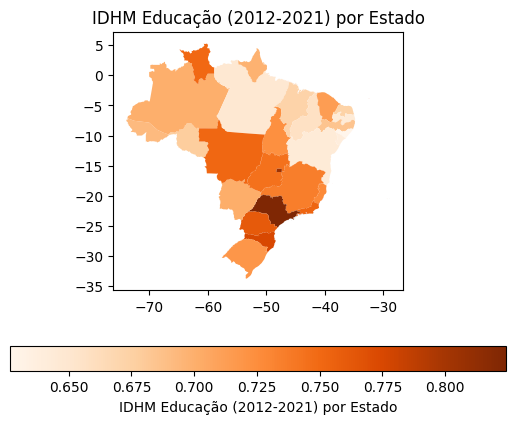

In [78]:


# Plotando o gráfico geoespacial com uma única cor
gdf_merge.plot(column='IDHM Educação média', 
               cmap='Oranges',  # Escolha uma cor única, como 'Oranges', 'Blues', etc.
               legend=True, 
               legend_kwds={'label': "IDHM Educação (2012-2021) por Estado", 'orientation': "horizontal"})

# Adicionar título
plt.title("IDHM Educação (2012-2021) por Estado")
plt.show()